In [16]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict, Literal, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
import operator
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

In [17]:
class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]


In [18]:
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [19]:
def chat_node(state: ChatState):

    #take user query from state
    messages=state["messages"]

    #send it to llm
    response = llm.invoke(messages)
    #response store in state
    return {'messages':[response]}

In [20]:
checkpointer = MemorySaver()
graph=StateGraph(ChatState)

#add nodes

graph.add_node('chat_node',chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node',END)

workflow=graph.compile(checkpointer=checkpointer)

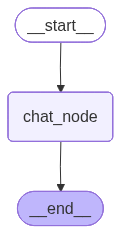

In [21]:
workflow

In [10]:
initial_state={
    'messages':[HumanMessage(content="What is the prompt engineering use in LLM")]
}
workflow.invoke(initial_state)['messages'][-1].content

'Prompt engineering is a crucial aspect of working with Large Language Models (LLMs). It refers to the process of designing and optimizing the input prompts or queries that are used to elicit specific, accurate, and relevant responses from an LLM.\n\nThe goal of prompt engineering is to craft prompts that are clear, concise, and well-defined, allowing the LLM to understand the context and generate high-quality responses. Here are some key aspects of prompt engineering in LLMs:\n\n1. **Specificity**: Well-designed prompts should be specific and unambiguous, avoiding vague or open-ended questions that can lead to unclear or irrelevant responses.\n2. **Contextualization**: Providing context is essential to help the LLM understand the topic, tone, and intent behind the prompt. This can include background information, definitions, or examples.\n3. **Format and structure**: The format and structure of the prompt can significantly impact the quality of the response. For example, using a speci

In [22]:
thread_id = '1'
while True:
    user_message = input('Type here: ')
    print("User: ",user_message)

    if user_message.strip().lower() in ['exit','quit','bye','stop']:
        break
    
    config = {'configurable':{'thread_id': thread_id}}
    response = workflow.invoke({'messages':[HumanMessage(content=user_message)]}, config=config)

    print('AI: ', response['messages'][-1].content)

User:  Hi my name is maaz
AI:  Hello Maaz, it's nice to meet you. Is there something I can help you with or would you like to chat?
User:  what is transformer in a child language in under 100 words
AI:  Hey Maaz, a transformer is a special robot that can change its shape. It can be a car, a plane, or even a robot! It's like a toy that can change into different things. Imagine you have a toy car that can turn into a robot, that's a transformer! It's so cool!
User:  no transformer in Llm ai ml
AI:  In AI and ML, a Transformer is a special computer model that helps machines understand and talk like humans. It's like a super smart brain that can learn from lots of words and sentences, and then use that knowledge to answer questions or have conversations. It's what makes chatbots like me work!
User:  ok what is my name
AI:  Your name is Maaz!
User:  bye


In [23]:
workflow.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='Hi my name is maaz', additional_kwargs={}, response_metadata={}, id='61f63801-5445-4524-900e-fc47bfe043fe'), AIMessage(content="Hello Maaz, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 41, 'total_tokens': 68, 'completion_time': 0.047750188, 'completion_tokens_details': None, 'prompt_time': 0.002208224, 'prompt_tokens_details': None, 'queue_time': 0.055270223, 'total_time': 0.049958412}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f12c9-00ba-70c0-b651-88f702928881-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 27, 'total_tokens': 68}), HumanMessage(content='what is transformer in a child langua